# Scenarios

In [36]:
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

In [1]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
# Import custom modules
import plotting
import utils

In [3]:
base_data_folder = os.path.join(os.path.dirname(os.getcwd()), "data", "processed")
folder_name = "elec_s_128_ES_PT_no_bat_limit"
data_folder = os.path.join(base_data_folder, folder_name)

In [4]:
input_data = utils.load_csv_files_from_folder(data_folder)
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
nodes

,x,y,country
bus,,,
ES1 0,-1.336936,37.857622,ES
ES1 1,-3.338053,42.904161,ES
ES1 2,-0.740836,41.700214,ES
ES1 3,-5.340267,37.243441,ES
ES1 4,-7.552214,42.691137,ES
ES1 5,-3.579551,40.127828,ES
ES1 6,-0.771890,39.438307,ES
ES1 7,-5.578100,40.986702,ES
ES1 8,1.630357,41.642177,ES


In [42]:
hourly_demand

,ES1 0,ES1 1,ES1 2,ES1 3,ES1 4,ES1 5,ES1 6,ES1 7,ES1 8,PT1 0,PT1 1
snapshot,,,,,,,,,,,
2013-01-01 00:00:00,1540.497187,3541.798151,1849.109695,2953.965919,2331.873044,3518.575677,2092.739520,1871.996365,2787.386472,2275.245735,2474.754265
2013-01-01 01:00:00,1433.747317,3296.366678,1720.974297,2749.268707,2170.284209,3274.753423,1947.721616,1742.275019,2594.232504,2182.798908,2374.201092
2013-01-01 02:00:00,1335.043919,3069.435065,1602.497346,2560.000934,2020.875437,3049.309730,1813.634710,1622.331663,2415.637880,2041.494173,2220.505827
2013-01-01 03:00:00,1273.019026,2926.831980,1528.046816,2441.065682,1926.987452,2907.641648,1729.374936,1546.959650,2303.409601,1916.954406,2085.045594
2013-01-01 04:00:00,1250.287740,2874.569876,1500.761703,2397.477519,1892.578775,2855.722211,1698.494867,1519.336825,2262.279453,1845.104541,2006.895459
...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 19:00:00,2047.626125,4707.751813,2457.833322,3926.406254,3099.521508,4676.884541,2781.665653,2488.254244,3704.989148,3105.830178,3378.169822
2013-12-31 20:00:00,1925.453849,4426.862275,2311.185901,3692.135952,2914.587553,4397.836710,2615.696670,2339.791748,3483.929770,2811.245730,3057.754270
2013-12-31 21:00:00,1773.509624,4077.523257,2128.802225,3400.776730,2684.587365,4050.788199,2409.282996,2155.150686,3209.000818,2655.092023,2887.907977


In [5]:
base_demand = hourly_demand.sum().sum()
base_demand

290278276.1728846

In [45]:
import pandas as pd

# Step 1: Create a mapping from node (bus) to country
bus_to_country = nodes["country"].to_dict()

# Step 2: Map columns to country
country_columns = hourly_demand.columns.map(bus_to_country)

# Step 3: Group by country and sum all time steps
total_demand_by_country = hourly_demand.groupby(by=country_columns, axis=1).sum().sum()

total_demand_by_country

C:\Users\tinus\AppData\Local\Temp\ipykernel_23900\3976117475.py:10: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  total_demand_by_country = hourly_demand.groupby(by=country_columns, axis=1).sum().sum()


ES    2.411740e+08
PT    4.910425e+07
dtype: float64

In [66]:
print(
    f"Demand percetage Portugal: {total_demand_by_country['PT'] / base_demand * 100:.2f}%"
)
print(
    f"Demand percetage Spain: {total_demand_by_country['ES'] / base_demand * 100:.2f}%"
)

Demand percetage Portugal: 16.92%
Demand percetage Spain: 83.08%


In [46]:
base_demand_spain = total_demand_by_country["ES"]
base_demand_portugal = total_demand_by_country["PT"]
base_demand_spain, base_demand_portugal

(241174021.67288452, 49104254.5)

In [6]:
def print_as_TWh(value):
    """Convert a value to TWh and print it with 2 decimal places."""
    print(f"{value / 1e6:.2f} TWh")

In [7]:
print_as_TWh(base_demand)

290.28 TWh


In [39]:
short_hand_to_full_name = {
    "NT": "National Trend",
    "GA": "Global Ambition",
    "DE": "Distributed Energy",
}
nt_2030 = 3264 * 1e6
nt_2040 = 3963 * 1e6
ga_2040 = 3617 * 1e6
ga_2050 = 3887 * 1e6
de_2040 = 4057 * 1e6
de_2050 = 4373 * 1e6
historical_2018 = 2745 * 1e6
estimate_2025 = historical_2018 + (nt_2030 - historical_2018) * (2025 - 2018) / (
    2030 - 2018
)
estimate_2025
print_as_TWh(estimate_2025)

3047.75 TWh


In [ ]:
estimate_2025_Iberia = historical_2018 + (nt_2030 - historical_2018) * (2025 - 2018) / (
    2030 - 2018
)

In [9]:
years = [2025, 2030, 2040, 2050]

In [10]:
# Assemble raw values per scenario
raw = {
    "NT": {2025: estimate_2025, 2030: nt_2030, 2040: nt_2040},
    "GA": {2025: estimate_2025, 2040: ga_2040, 2050: ga_2050},
    "DE": {2025: estimate_2025, 2040: de_2040, 2050: de_2050},
}

# Desired year order
years = [2025, 2030, 2040, 2050]

# Create DataFrame and reindex rows
df = pd.DataFrame(raw).reindex(years)

# Divide each column by its 2025 value to get scalars
scenario_multiplier = df.div(df.loc[2025])
scenario_multiplier.loc[2025, "GA"] = pd.NA
scenario_multiplier.loc[2025, "DE"] = pd.NA
scenario_multiplier

,NT,GA,DE
2025,1.000000,NaN,NaN
2030,1.070954,NaN,NaN
2040,1.300304,1.186777,1.331146
2050,NaN,1.275367,1.434829


In [11]:
total_demands = scenario_multiplier * estimate_2025 / 1e6

In [12]:
# Define path and filename
folder = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers"
filename = "base_scenarios.csv"
full_path = os.path.join(folder, filename)

# Ensure the directory exists
os.makedirs(folder, exist_ok=True)

# Save to CSV (including the year as the index)
scenario_multiplier.to_csv(full_path, index=True)

print(f"Saved scenario_multiplier to {full_path}")

Saved scenario_multiplier to C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\base_scenarios.csv


In [13]:
scenario_multiplier.index.values

print(set(scenario_multiplier.index.values) == set(years))

True


In [14]:
# Build the dictionary
scenarios = {
    year: [name for name in scenario_multiplier.loc[year].dropna().index]
    for year in scenario_multiplier.index
}

print(scenarios)

{2025: ['NT'], 2030: ['NT'], 2040: ['NT', 'GA', 'DE'], 2050: ['GA', 'DE']}


In [15]:
scenario_multiplier.index.values.tolist()

[2025, 2030, 2040, 2050]

In [30]:
estimate_2025 / 1e6

3047.75

### Plot

In [35]:
folder_path = os.path.join(
    os.path.dirname(os.getcwd()), "data", "for_the_report", "methodology", "demand"
)
folder_path

'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\data\\for_the_report\\methodology\\demand'

Projected Demand by Scenario (Line Chart)


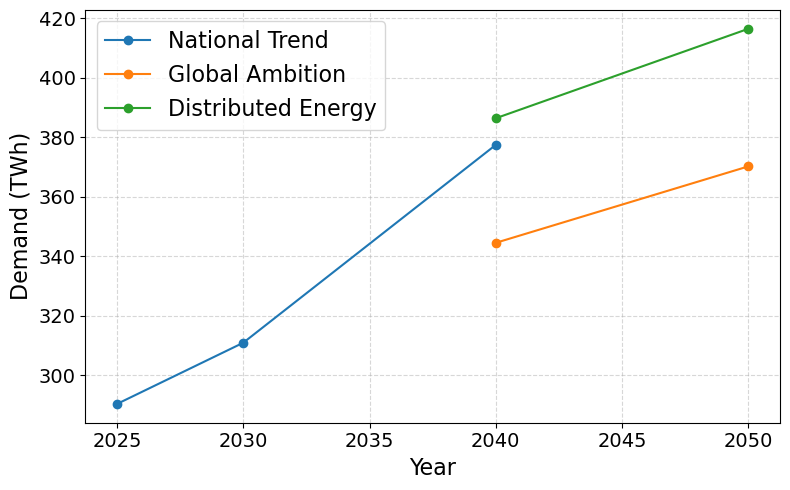

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Compute demand projections in TWh
demand_proj = scenario_multiplier.multiply(base_demand) / 1e6  # TWh

# Print title instead of embedding it in the figure
print("Projected Demand by Scenario (Line Chart)")

plt.figure(figsize=(8, 5))
for scen in demand_proj.columns:
    plt.plot(
        demand_proj.index,
        demand_proj[scen],
        label=short_hand_to_full_name[scen],
        color=scenario_colors[scen],
        marker="o",
    )

# Apply styling
plt.xlabel("Year", fontsize=16)
plt.ylabel("Demand (TWh)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

# Save figure
os.makedirs(folder_path, exist_ok=True)
plt.savefig(os.path.join(folder_path, "projected_demand_by_scenario.png"))

plt.show()

Projected Demand by Scenario (Bar Chart)


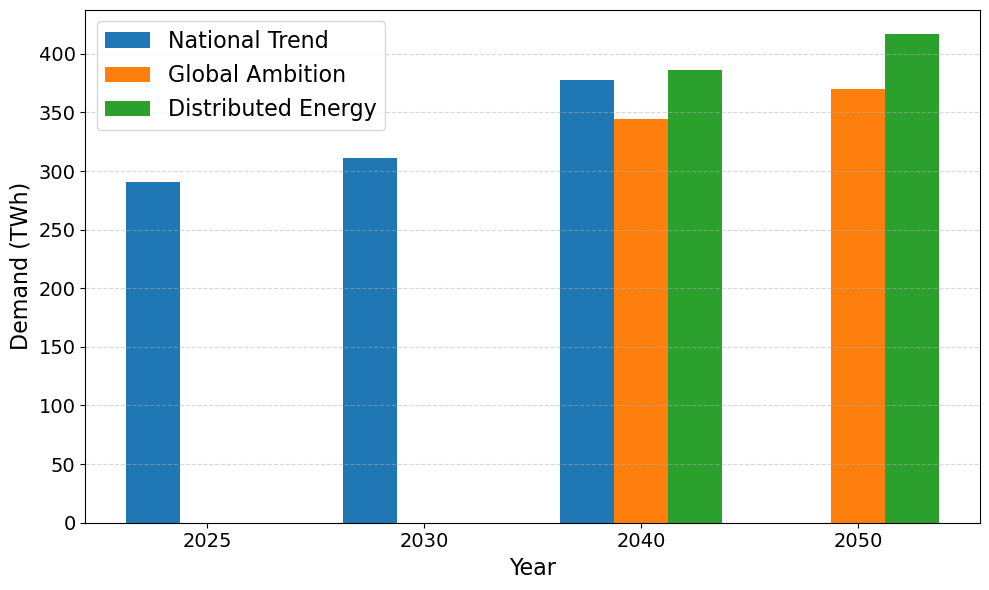

In [52]:
import numpy as np

# Compute demand projections in TWh
demand_proj = scenario_multiplier.multiply(base_demand) / 1e6  # TWh

# Print title instead of embedding it in the figure
print("Projected Demand by Scenario (Bar Chart)")

plt.figure(figsize=(10, 6))

years = demand_proj.index.tolist()
scenarios = demand_proj.columns.tolist()
bar_width = 0.25
x = np.arange(len(years))  # base positions for bars

for i, scen in enumerate(scenarios):
    values = demand_proj[scen].values
    plt.bar(
        x + i * bar_width,
        values,
        width=bar_width,
        label=short_hand_to_full_name[scen],
        color=scenario_colors[scen],
    )

# Apply styling
plt.xlabel("Year", fontsize=16)
plt.ylabel("Demand (TWh)", fontsize=16)
plt.xticks(x + bar_width * (len(scenarios) - 1) / 2, years, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(folder_path, "projected_demand_by_scenario_bars.png"))

plt.show()

Projected Demand by Scenario and Country (Stacked Bar Chart)


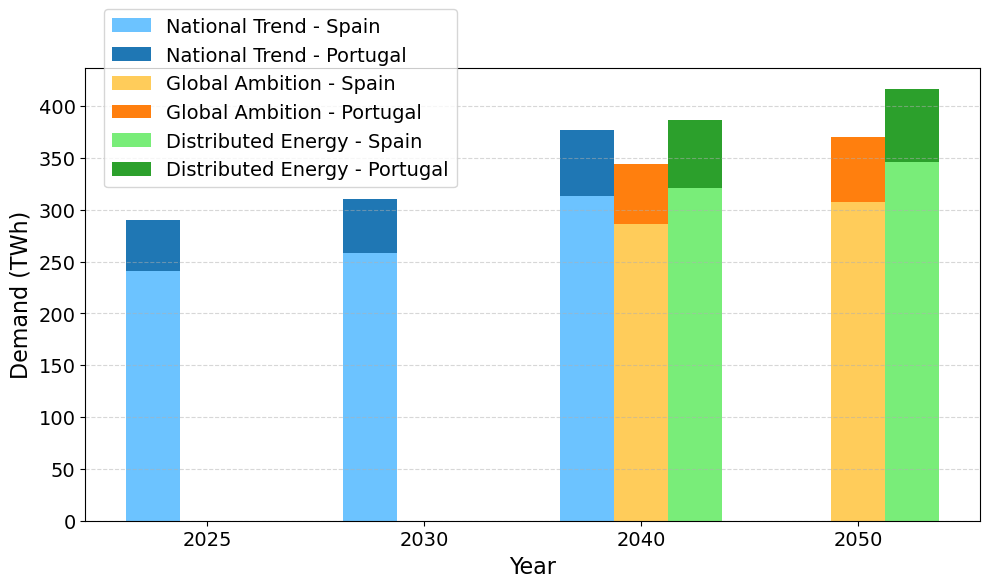

In [60]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Compute projections for Spain and Portugal
demand_spain = scenario_multiplier.multiply(base_demand_spain) / 1e6  # TWh
demand_portugal = scenario_multiplier.multiply(base_demand_portugal) / 1e6  # TWh

# Print title instead of embedding in plot
print("Projected Demand by Scenario and Country (Stacked Bar Chart)")

plt.figure(figsize=(10, 6))

years = scenario_multiplier.index.tolist()
scenarios = scenario_multiplier.columns.tolist()
bar_width = 0.25
x = np.arange(len(years))

for i, scen in enumerate(scenarios):
    values_spain = demand_spain[scen].values
    values_portugal = demand_portugal[scen].values

    # Define colors
    color_portugal = scenario_colors[scen]
    color_spain = (
        pd.Series(color_portugal)
        .apply(lambda c: tuple(np.clip(np.array(mcolors.to_rgb(c)) + 0.3, 0, 1)))
        .iloc[0]
    )  # lighter version

    # Plot Spain (bottom of stack)
    plt.bar(
        x + i * bar_width,
        values_spain,
        width=bar_width,
        label=f"{short_hand_to_full_name[scen]} - Spain",
        color=color_spain,
    )

    # Plot Portugal (on top of Spain)
    plt.bar(
        x + i * bar_width,
        values_portugal,
        width=bar_width,
        bottom=values_spain,
        label=f"{short_hand_to_full_name[scen]} - Portugal",
        color=color_portugal,
    )

# Axis & style
plt.xlabel("Year", fontsize=16)
plt.ylabel("Demand (TWh)", fontsize=16)
plt.xticks(x + bar_width * (len(scenarios) - 1) / 2, years, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(
    fontsize=14,
    loc="upper left",
    bbox_to_anchor=(0.01, 1.15),  # x: a bit from the left, y: just above the top
)


plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# Save figure
os.makedirs(folder_path, exist_ok=True)
plt.savefig(os.path.join(folder_path, "projected_demand_by_scenario_stacked.png"))

plt.show()

Projected Demand by Scenario (Relative to 2025 National Trend)


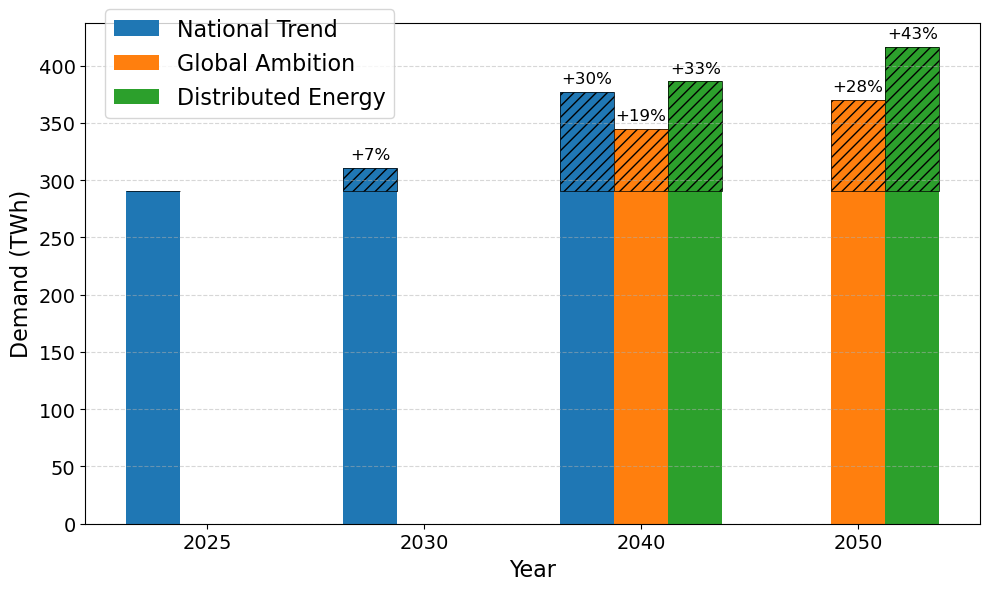

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Compute demand projections in TWh
demand_proj = scenario_multiplier.multiply(base_demand) / 1e6  # TWh

# Use 2025 National Trend as baseline
base_2025 = demand_proj.loc[2025, "NT"]

# Print title instead of embedding in plot
print("Projected Demand by Scenario (Relative to 2025 National Trend)")

plt.figure(figsize=(10, 6))

years = demand_proj.index.tolist()
scenarios = demand_proj.columns.tolist()
bar_width = 0.25
x = np.arange(len(years))  # base positions

for i, scen in enumerate(scenarios):
    values = demand_proj[scen].values
    xpos = x + i * bar_width
    base_color = scenario_colors[scen]

    # Plot base bars (full height, solid color)
    plt.bar(
        xpos,
        values,
        width=bar_width,
        color=base_color,
        label=short_hand_to_full_name[scen],
    )

    # Overlay hatched part only above baseline
    growth = np.maximum(values - base_2025, 0)
    plt.bar(
        xpos,
        growth,
        width=bar_width,
        bottom=base_2025,
        color=base_color,
        hatch="///",
        edgecolor="black",
        linewidth=0.5,
    )

    # Add % increase labels
    for j, year in enumerate(years):
        pct = 100 * (values[j] - base_2025) / base_2025
        if pct > 0:
            plt.text(
                xpos[j],
                values[j] + 5,
                f"+{pct:.0f}%",
                ha="center",
                va="bottom",
                fontsize=12,
            )

# Apply styling
plt.xlabel("Year", fontsize=16)
plt.ylabel("Demand (TWh)", fontsize=16)
plt.xticks(x + bar_width * (len(scenarios) - 1) / 2, years, fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16, loc="upper left", bbox_to_anchor=(0.01, 1.05))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(folder_path, "projected_demand_relative_to_NT2025_hatched.png")
)

plt.show()

### Making scenario trees

In [16]:
from itertools import product

# Create a list of all combinations of years and scenarios
combinations = list(product(scenario_multiplier.index.values, scenarios.values()))

In [17]:
options_per_year = [scenarios[year] for year in years]
scenario_trees = list(product(*options_per_year))

In [18]:
scenario_trees

[('NT', 'NT', 'NT', 'GA'),
 ('NT', 'NT', 'NT', 'DE'),
 ('NT', 'NT', 'GA', 'GA'),
 ('NT', 'NT', 'GA', 'DE'),
 ('NT', 'NT', 'DE', 'GA'),
 ('NT', 'NT', 'DE', 'DE')]

In [19]:
from itertools import product

# Your input dictionary
scenarios = {2025: ["NT"], 2030: ["NT"], 2040: ["NT", "GA", "DE"], 2050: ["GA", "DE"]}

# Get the years in sorted order for consistent output
years = sorted(scenarios)

# Get the list of scenario options for each year
options_per_year = [scenarios[year] for year in years]

# Compute the Cartesian product to get all scenario tree combinations
scenario_trees = list(product(*options_per_year))

# Optional: format as list of dicts for clarity
formatted_trees = [dict(zip(years, combo)) for combo in scenario_trees]

# Print results
for tree in formatted_trees:
    print(tree)

{2025: 'NT', 2030: 'NT', 2040: 'NT', 2050: 'GA'}
{2025: 'NT', 2030: 'NT', 2040: 'NT', 2050: 'DE'}
{2025: 'NT', 2030: 'NT', 2040: 'GA', 2050: 'GA'}
{2025: 'NT', 2030: 'NT', 2040: 'GA', 2050: 'DE'}
{2025: 'NT', 2030: 'NT', 2040: 'DE', 2050: 'GA'}
{2025: 'NT', 2030: 'NT', 2040: 'DE', 2050: 'DE'}


In [20]:
options_per_year

[['NT'], ['NT'], ['NT', 'GA', 'DE'], ['GA', 'DE']]

In [21]:
# Process each tree
scenario_dfs = []
for i, tree in enumerate(formatted_trees):
    # Create a mask: True for entries that match the selected scenario, False otherwise
    mask = pd.DataFrame(
        False, index=scenario_multiplier.index, columns=scenario_multiplier.columns
    )
    for year, scen in tree.items():
        mask.loc[year, scen] = True

    # Apply the mask
    filtered_df = scenario_multiplier.where(mask)

    # Drop columns that are entirely NaN
    filtered_df = filtered_df.dropna(axis=1, how="all")

    scenario_dfs.append(filtered_df)

    # Optional: label and display
    print(f"\nScenario Tree {i + 1}: {tree}")
    print(filtered_df)


Scenario Tree 1: {2025: 'NT', 2030: 'NT', 2040: 'NT', 2050: 'GA'}
            NT        GA
2025  1.000000       NaN
2030  1.070954       NaN
2040  1.300304       NaN
2050       NaN  1.275367

Scenario Tree 2: {2025: 'NT', 2030: 'NT', 2040: 'NT', 2050: 'DE'}
            NT        DE
2025  1.000000       NaN
2030  1.070954       NaN
2040  1.300304       NaN
2050       NaN  1.434829

Scenario Tree 3: {2025: 'NT', 2030: 'NT', 2040: 'GA', 2050: 'GA'}
            NT        GA
2025  1.000000       NaN
2030  1.070954       NaN
2040       NaN  1.186777
2050       NaN  1.275367

Scenario Tree 4: {2025: 'NT', 2030: 'NT', 2040: 'GA', 2050: 'DE'}
            NT        GA        DE
2025  1.000000       NaN       NaN
2030  1.070954       NaN       NaN
2040       NaN  1.186777       NaN
2050       NaN       NaN  1.434829

Scenario Tree 5: {2025: 'NT', 2030: 'NT', 2040: 'DE', 2050: 'GA'}
            NT        GA        DE
2025  1.000000       NaN       NaN
2030  1.070954       NaN       NaN
2040      

In [22]:
import os

# Folder path where files will be saved
folder = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers"

# Ensure the folder exists
os.makedirs(folder, exist_ok=True)

# Save each DataFrame to a CSV file
for i, df in enumerate(scenario_dfs, start=1):
    filename = f"EVPI_{i}.csv"
    full_path = os.path.join(folder, filename)
    df.to_csv(full_path)
    print(f"Saved: {full_path}")

Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_1.csv
Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_2.csv
Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_3.csv
Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_4.csv
Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_5.csv
Saved: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\EVPI_6.csv


In [23]:
# Compute the average multiplier per year, ignoring NaNs
average_multiplier = scenario_multiplier.mean(axis=1, skipna=True)

# Convert to a new DataFrame
average_df = pd.DataFrame({"mean": average_multiplier})

# Display the result
print(average_df)

          mean
2025  1.000000
2030  1.070954
2040  1.272742
2050  1.355098


In [24]:
# Define the folder path
folder = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers"

# Create the full path for the output file
mean_path = os.path.join(folder, "mean.csv")

# Save the DataFrame
average_df.to_csv(mean_path)

print(f"Saved mean scenario multiplier to: {mean_path}")

Saved mean scenario multiplier to: C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\scenario_multipliers\mean.csv
